<a href="https://colab.research.google.com/github/fc63/gender-classification/blob/main/lr_finder/lrfinder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets transformers torch evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import warnings
import evaluate
import pandas as pd
import numpy as np
import os
import re
import pickle
import gc
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, TrainerCallback
from tqdm import tqdm
from google.colab import drive
from transformers import EarlyStoppingCallback

drive.mount('/content/drive')

with open('/content/drive/MyDrive/datasets/europarl_normalized.pkl', 'rb') as f:
    df = pickle.load(f)

Mounted at /content/drive


In [3]:
print(df['gender'].value_counts())

min_count = df['gender'].value_counts().min()

df = (
    df.groupby('gender', group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=63))
    .reset_index(drop=True)
)

print(df['gender'].value_counts())

gender
male      740894
female    360361
Name: count, dtype: int64
gender
female    360361
male      360361
Name: count, dtype: int64


<ipython-input-3-e34e100695cf>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count, random_state=63))


In [4]:
# encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['gender'])

df

,text,gender,label
0,"Cooperation is not only in our interest, but i...",female,0
1,"During the committee's first meeting, we enter...",female,0
2,"Towards the end of the debate on the matter, a...",female,0
3,"After all, something is obviously being set in...",female,0
4,"Today, the new Member States in particular req...",female,0
...,...,...,...
720717,"Their function, as I understand it, is to diss...",male,1
720718,That is my first point.,male,1
720719,What we need to do tomorrow is to accept the c...,male,1
720720,in writing. I welcome this report which:,male,1


In [5]:
print(label_encoder.classes_)
print(df['label'].value_counts())

['female' 'male']
label
0    360361
1    360361
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-6-9268de361402>:72: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]

Step,Training Loss
1,0.691600
2,0.683500
3,0.713200
4,0.709400
5,0.709500
6,0.698400
7,0.716300
8,0.709800
9,0.701700
10,0.738800


Step 1 | LR: 1.00e-06 | Loss: 0.6916
Step 2 | LR: 1.04e-06 | Loss: 0.6835
Step 3 | LR: 1.08e-06 | Loss: 0.7132
Step 4 | LR: 1.12e-06 | Loss: 0.7094
Step 5 | LR: 1.17e-06 | Loss: 0.7095
Step 6 | LR: 1.22e-06 | Loss: 0.6984
Step 7 | LR: 1.26e-06 | Loss: 0.7163
Step 8 | LR: 1.32e-06 | Loss: 0.7098
Step 9 | LR: 1.37e-06 | Loss: 0.7017
Step 10 | LR: 1.42e-06 | Loss: 0.7388
Step 11 | LR: 1.48e-06 | Loss: 0.6886
Step 12 | LR: 1.54e-06 | Loss: 0.7248
Step 13 | LR: 1.60e-06 | Loss: 0.7033
Step 14 | LR: 1.66e-06 | Loss: 0.7326
Step 15 | LR: 1.73e-06 | Loss: 0.7173
Step 16 | LR: 1.80e-06 | Loss: 0.7191
Step 17 | LR: 1.87e-06 | Loss: 0.7140
Step 18 | LR: 1.94e-06 | Loss: 0.7052
Step 19 | LR: 2.02e-06 | Loss: 0.7019
Step 20 | LR: 2.10e-06 | Loss: 0.7137
Step 21 | LR: 2.19e-06 | Loss: 0.7288
Step 22 | LR: 2.27e-06 | Loss: 0.6949
Step 23 | LR: 2.36e-06 | Loss: 0.6986
Step 24 | LR: 2.46e-06 | Loss: 0.6789
Step 25 | LR: 2.56e-06 | Loss: 0.7222
Step 26 | LR: 2.66e-06 | Loss: 0.7121
Step 27 | LR: 2.77e-0

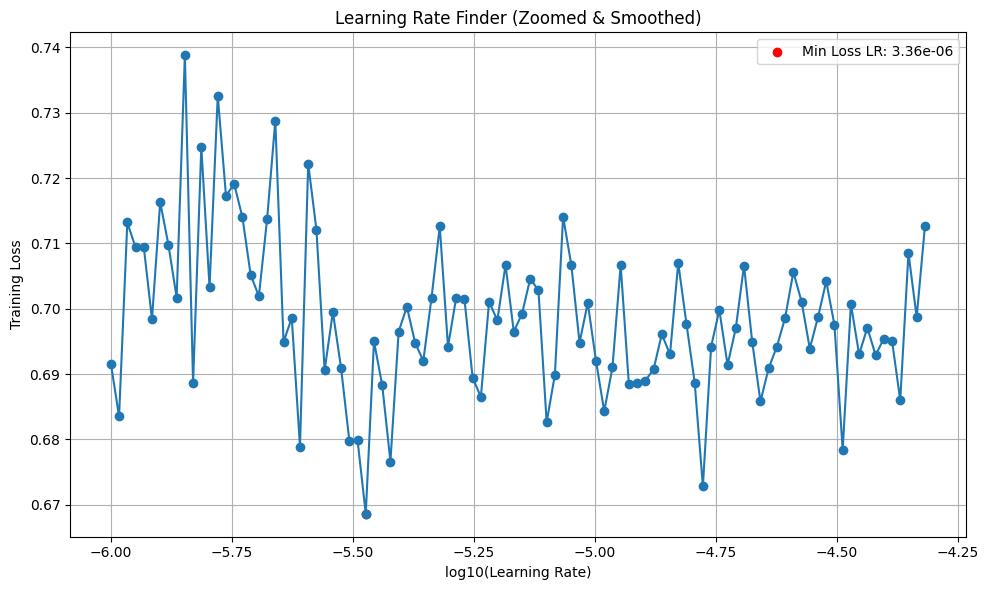

In [6]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.21, random_state=63)

# tokenization for huggingfaceapi
train_df = {"text": list(X_train), "label": list(y_train)}
test_df = {"text": list(X_test), "label": list(y_test)}
train_dataset = Dataset.from_dict(train_df)
eval_dataset = Dataset.from_dict(test_df)
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-large", use_fast=False)
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
train_dataset = train_dataset.map(tokenize_function, batched=True)
eval_dataset = eval_dataset.map(tokenize_function, batched=True)
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

class LRFinderCallback(TrainerCallback):
    def __init__(self, start_lr=1e-7, end_lr=1e-1, num_iters=100):
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.num_iters = num_iters
        self.lrs = []
        self.losses = []
        self.step = 0

    def on_log(self, args, state, control, logs=None, **kwargs):
        if self.step >= self.num_iters:
            control.should_training_stop = True
            return control

        lr = self.start_lr * (self.end_lr / self.start_lr) ** (self.step / self.num_iters)
        for group in kwargs["optimizer"].param_groups:
            group["lr"] = lr

        loss = logs.get("loss") if logs else None

        if loss is not None:
            print(f"Step {self.step+1} | LR: {lr:.2e} | Loss: {loss:.4f}")
            self.lrs.append(lr)
            self.losses.append(loss)
            self.step += 1

        return control

from transformers import TrainingArguments, Trainer
from transformers import AutoModelForSequenceClassification
import numpy as np
import matplotlib.pyplot as plt

subset_train = train_dataset.select(range(40960))

model = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-v3-large", num_labels=2)

training_args = TrainingArguments(
    output_dir="output",
    num_train_epochs=1,
    per_device_train_batch_size=64,
    logging_steps=1,
    eval_strategy="no",
    save_strategy="no",
    report_to="none",
    fp16=True,
)

lr_finder = LRFinderCallback(start_lr=1e-6, end_lr=5e-5, num_iters=100)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=subset_train,
    tokenizer=tokenizer,
    compute_metrics=None,
    callbacks=[lr_finder]
)

trainer.train()

lrs = np.array(lr_finder.lrs)
losses = np.array(lr_finder.losses)
log_lrs = np.log10(lrs)

# ⬇️ Buraya fonksiyonu ekle
def suggest_lr_from_curve(lrs, losses, mode="steepest"):
    lrs = np.array(lrs)
    losses = np.array(losses)

    if mode == "steepest":
        log_lrs = np.log10(lrs)
        grads = np.gradient(losses, log_lrs)
        min_grad_idx = np.argmin(grads)
        suggested_lr = lrs[min_grad_idx]
        reason = "steepest loss drop"

    elif mode == "min_loss":
        min_idx = np.argmin(losses)
        suggested_lr = lrs[max(min_idx - 1, 0)]
        reason = "just before min loss"

    else:
        raise ValueError("Mode must be 'steepest' or 'min_loss'")

    print(f"📌 Suggested LR ({reason}): {suggested_lr:.2e}")
    return suggested_lr

# 🔍 En iyi LR tahmini
suggest_lr_from_curve(lrs, losses, mode="steepest")

# Grafik çizimi
plt.figure(figsize=(10, 6))
plt.plot(log_lrs, losses, marker='o', linestyle='-')
plt.xlabel("log10(Learning Rate)")
plt.ylabel("Training Loss")
plt.title("Learning Rate Finder (Zoomed & Smoothed)")
plt.grid(True)

min_idx = np.argmin(losses)
plt.scatter(log_lrs[min_idx], losses[min_idx], color='red', label=f"Min Loss LR: {lrs[min_idx]:.2e}")
plt.legend()
plt.tight_layout()
plt.show()